# Gráficos Bibliometrix - WOS vs1

Este notebook gera gráficos de linha e barras (horizontal) para cada análise presente no arquivo Excel do Bibliometrix.

In [1]:
# Importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurar estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Caminho do arquivo Excel
excel_path = 'bibliometrix_wos.xlsx'
output_dir = 'graficos_wos_vs1'


In [2]:
# Ler arquivo Excel
xl = pd.ExcelFile(excel_path)
print(f"Arquivo Excel carregado: {excel_path}")
print(f"Total de abas: {len(xl.sheet_names)}")

Arquivo Excel carregado: bibliometrix_wos.xlsx
Total de abas: 37


## 1. Produção Científica Anual

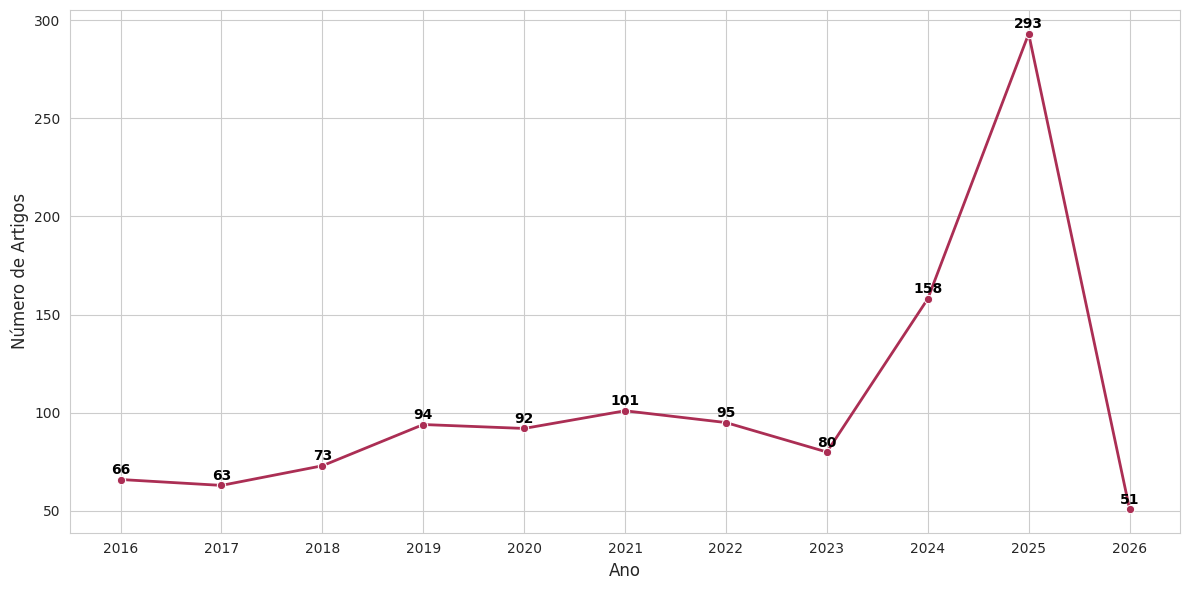

Gráfico salvo: graficos_wos_vs1/fig1_prod_cient_anual.png


In [3]:
# 1. AnnualSciProd - Produção Científica Anual
df = pd.read_excel(xl, sheet_name='AnnualSciProd')

# Gráfico de linha
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Articles', marker='o', linewidth=2, color="#AB2E54")
for i in range(len(df)):
    plt.text(df['Year'].iloc[i],          # Posição X
             df['Articles'].iloc[i] + 1.2, # Posição Y (Aumente o 1.2 se precisar de mais espaço)
             str(df['Articles'].iloc[i]), # O texto (valor)
             ha='center',                 # Alinhamento horizontal
             va='bottom',                 # Alinhamento vertical (base no fundo)
             fontsize=10, 
             fontweight='bold',
             color="#000000")  
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Número de Artigos', fontsize=12)
plt.xticks(df['Year'])
plt.tight_layout()
plt.savefig(f'{output_dir}/fig1_prod_cient_anual.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig1_prod_cient_anual.png")

## 2. Citações por Ano

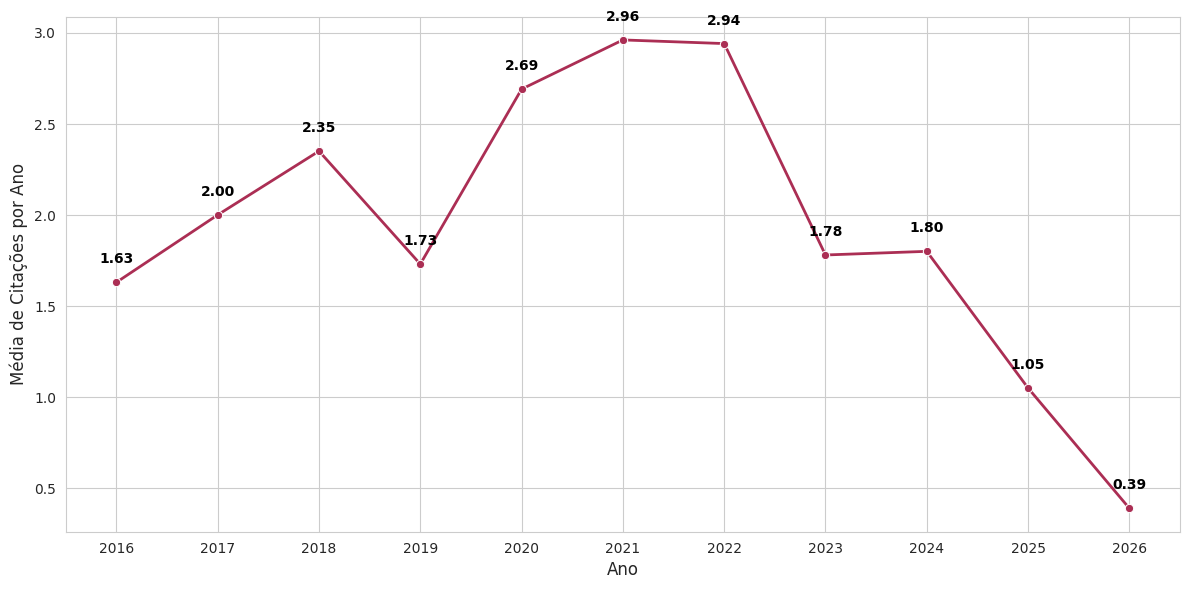

Gráfico salvo: graficos_wos_vs1/fig2_citacoes_por_ano.png


In [4]:
# 2. AnnualCitPerYear - Citações por Ano
df = pd.read_excel(xl, sheet_name='AnnualCitPerYear')

# Gráfico de linha
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='MeanTCperYear', marker='o', linewidth=2, color='#AB2E54')
for i in range(len(df)):
    valor = df['MeanTCperYear'].iloc[i]
    plt.text(df['Year'].iloc[i], 
             valor + (df['MeanTCperYear'].max() * 0.03), # Desloca 3% do valor máximo para cima
             f'{valor:.2f}', # Exibe com 2 casas decimais
             ha='center', 
             va='bottom', 
             fontsize=10, 
             fontweight='bold', 
             color="#000000")
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Média de Citações por Ano', fontsize=12)
plt.xticks(df['Year'])
plt.tight_layout()
plt.savefig(f'{output_dir}/fig2_citacoes_por_ano.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig2_citacoes_por_ano.png")

## 3. Fontes Mais Relevantes

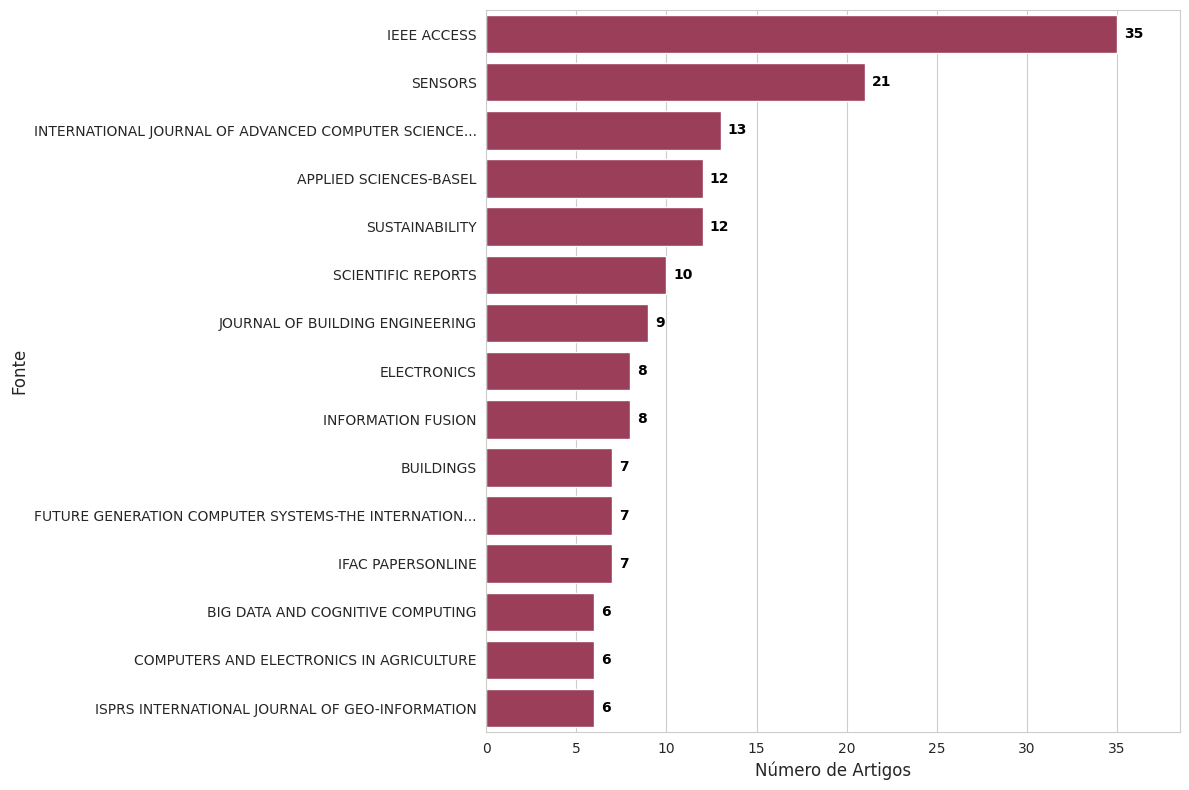

Gráfico salvo: graficos_wos_vs1/fig3_fontes_mais_relevantes.png


In [5]:
df = pd.read_excel(xl, sheet_name='MostRelSources').head(15)

# Limpar nomes das fontes
df['Sources'] = df['Sources'].apply(lambda x: x[:50] + '...' if len(str(x)) > 50 else x)

plt.figure(figsize=(12, 8))
# Trocado 'palette' por 'color' para cor única
ax = sns.barplot(data=df, x='Articles', y='Sources', color='#AB2E54', orient='h')

# Adiciona os valores após as barras
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold', color="#000000")

# Aumentar o limite do eixo X para o número não ficar cortado na borda
plt.xlim(0, df['Articles'].max() * 1.1)

#plt.title('Fontes Mais Relevantes - Scopus', fontsize=14, fontweight='bold')
plt.xlabel('Número de Artigos', fontsize=12)
plt.ylabel('Fonte', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig3_fontes_mais_relevantes.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig3_fontes_mais_relevantes.png")

## 4. Autores Mais Relevantes por Artigos

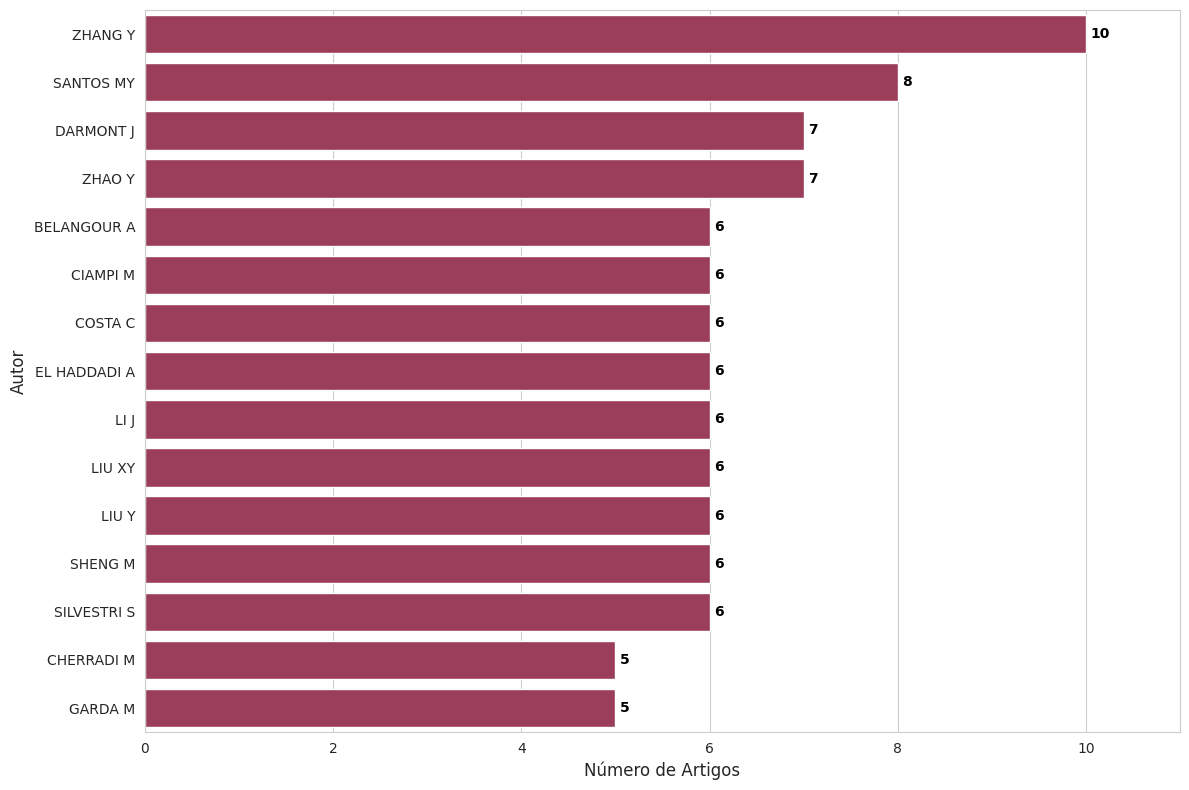

Gráfico salvo: graficos_wos_vs1/fig4_autores_mais_relevantes.png


In [6]:
# 4. MostRelAuthors - Autores Mais Relevantes
df = pd.read_excel(xl, sheet_name='MostRelAuthors').head(15)

plt.figure(figsize=(12, 8))
# Trocado palette por color para manter o padrão #2E86AB
ax = sns.barplot(data=df, x='Articles', y='Authors', color='#AB2E54', orient='h')

# Adiciona os valores logo após as barras (com um pequeno recuo de 3 pixels)
ax.bar_label(ax.containers[0], padding=3, fontsize=10, fontweight='bold', color="#000000")

# Garante que o eixo X tenha espaço para os números não serem cortados
plt.xlim(0, df['Articles'].max() * 1.1)

#plt.title('Autores Mais Relevantes por Número de Artigos - Scopus', fontsize=14, fontweight='bold')
plt.xlabel('Número de Artigos', fontsize=12)
plt.ylabel('Autor', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig4_autores_mais_relevantes.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig4_autores_mais_relevantes.png")


## 5. Autores Mais Citados Localmente

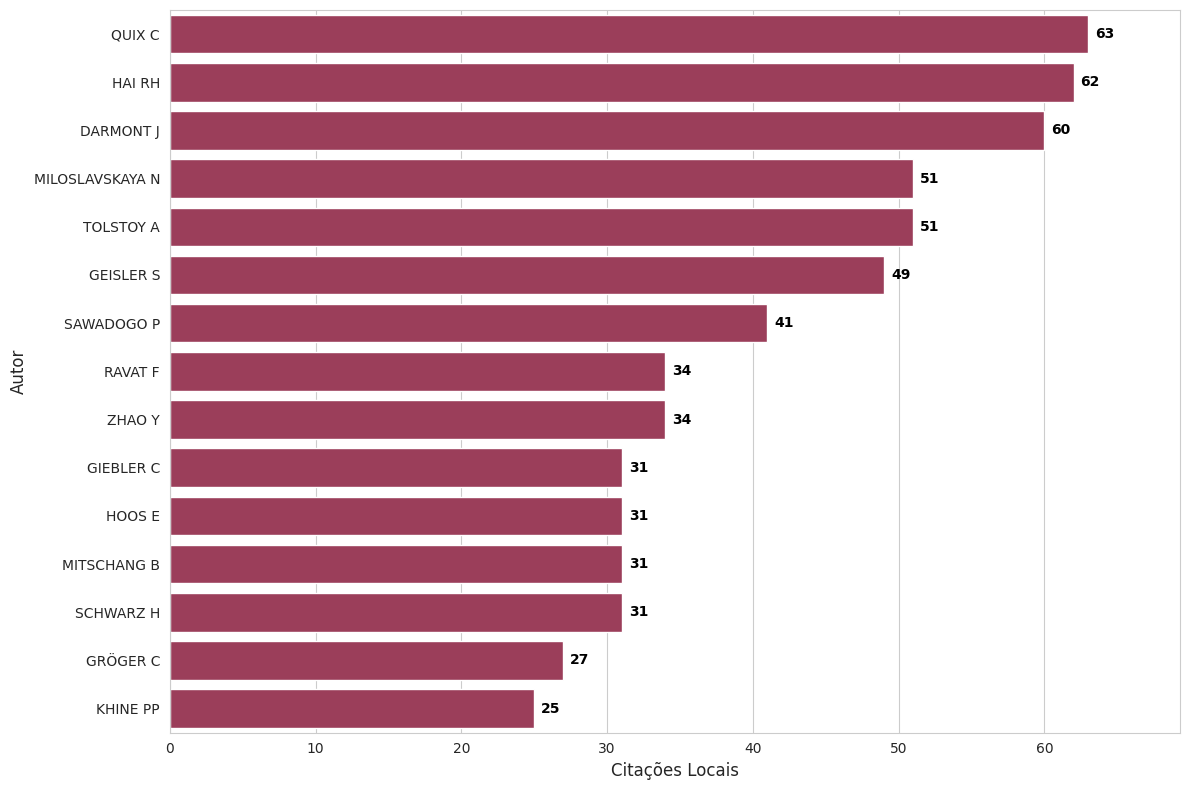

Gráfico salvo: graficos_wos_vs1/fig5_autores_mais_citados.png


In [7]:
# 5. MostLocCitAuthors - Autores Mais Citados Localmente
df = pd.read_excel(xl, sheet_name='MostLocCitAuthors').head(15)

plt.figure(figsize=(12, 8))

# Removido palette e adicionado color fixo para evitar erros de versão do Seaborn
ax = sns.barplot(data=df, x='LocalCitations', y='Author', color='#AB2E54', orient='h')

# Adiciona os valores após as barras
# Nota: ax.containers funciona a partir do Matplotlib 3.4+
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold', color="#000000")

# Dá um respiro no eixo X para o número não sumir
plt.xlim(0, df['LocalCitations'].max() * 1.1)

#plt.title('Autores Mais Citados Localmente - Scopus', fontsize=14, fontweight='bold')
plt.xlabel('Citações Locais', fontsize=12)
plt.ylabel('Autor', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig5_autores_mais_citados.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig5_autores_mais_citados.png")


## 6. Impacto Local dos Autores

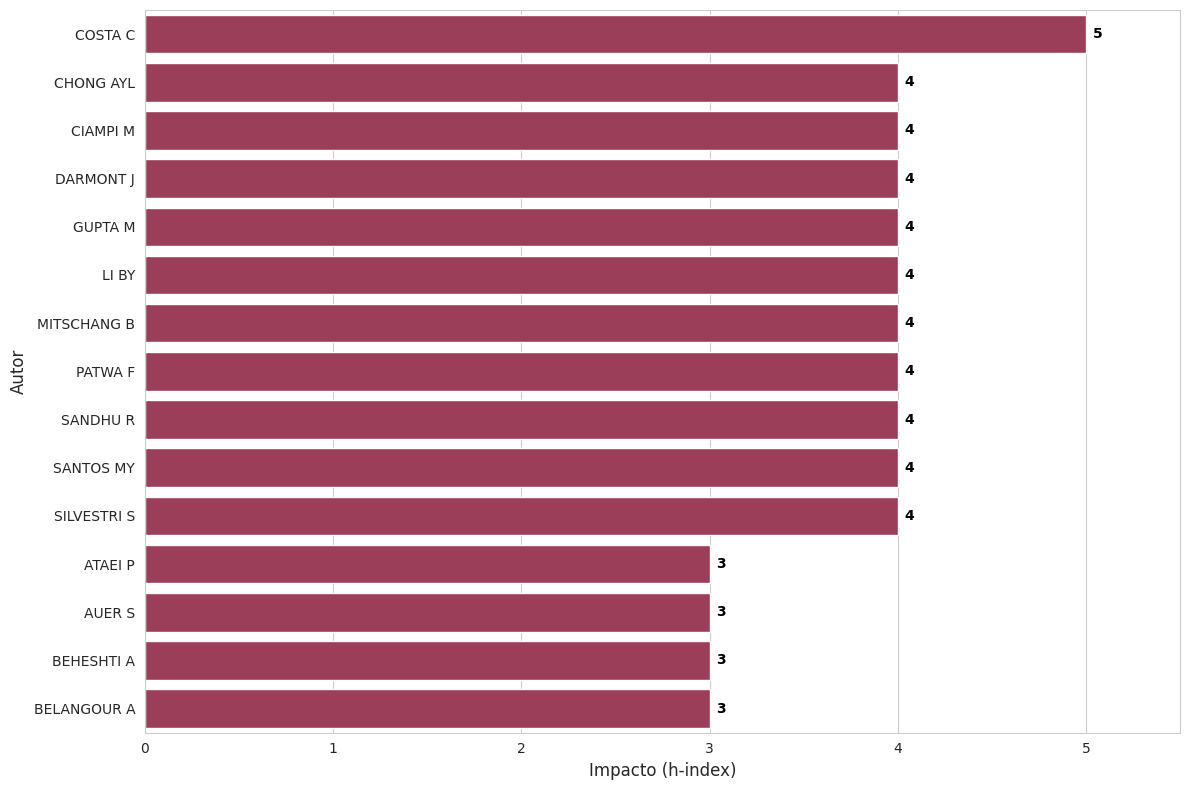

Gráfico salvo: graficos_wos_vs1/fig6_impacto_local_autores.png


In [8]:
# 6. AuthorLocImpact - Impacto Local dos Autores
df = pd.read_excel(xl, sheet_name='AuthorLocImpact').head(15)

plt.figure(figsize=(12, 8))

# Usando color='#2E86AB' para manter a consistência com os anteriores
ax = sns.barplot(data=df, x='h_index', y='Author', color='#AB2E54', orient='h')

# Adicionando os valores (Total de Citações) ao lado das barras
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold', color="#000000")

# Ajustando o limite do eixo X para o valor final não ser cortado
plt.xlim(0, df['h_index'].max() * 1.1)

#plt.title('Impacto Local dos Autores (Total de Citações) - Scopus', fontsize=14, fontweight='bold')
plt.xlabel('Impacto (h-index)', fontsize=12)
plt.ylabel('Autor', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig6_impacto_local_autores.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig6_impacto_local_autores.png")


## 7. Afiliações Mais Relevantes

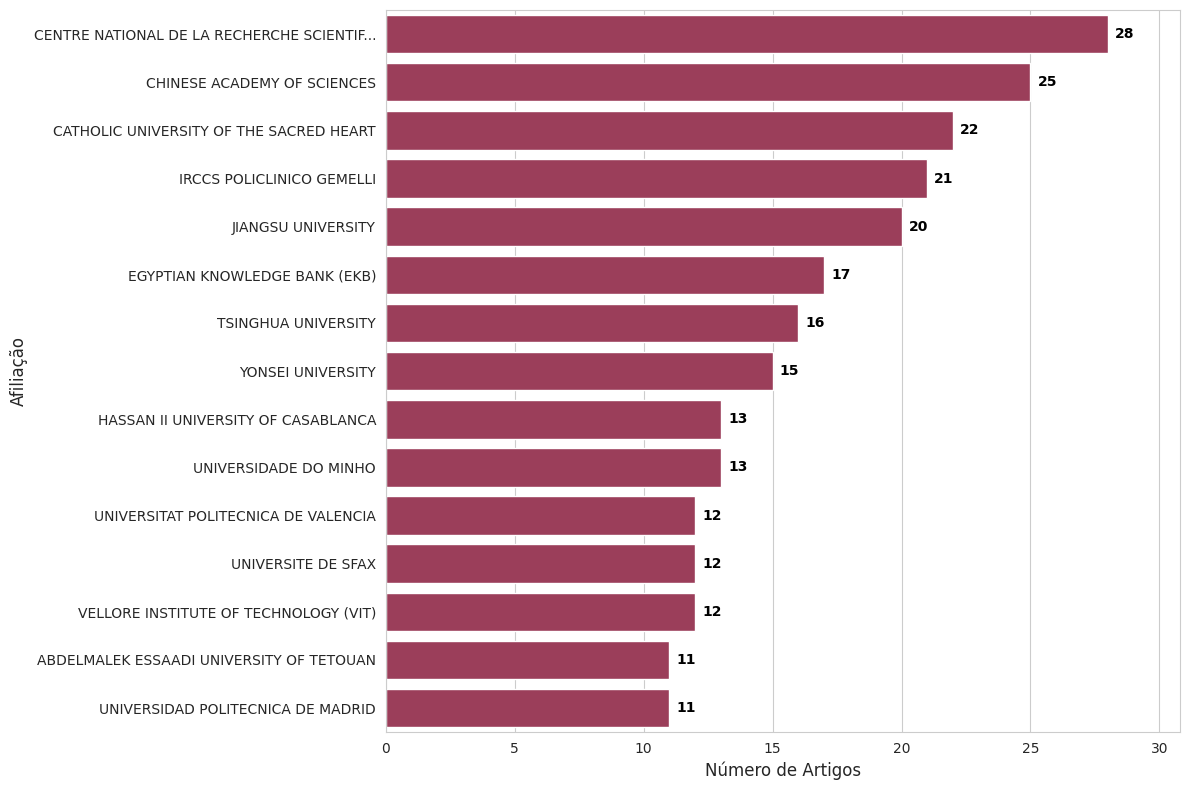

Gráfico salvo: graficos_wos_vs1/fig7_afiliacoes_mais_relevantes.png


In [9]:
# 7. MostRelAffiliations - Afiliações Mais Relevantes
df = pd.read_excel(xl, sheet_name='MostRelAffiliations').head(15)

# Limpar nomes das instituições
df['Affiliation'] = df['Affiliation'].apply(lambda x: x[:40] + '...' if len(str(x)) > 40 else x)

plt.figure(figsize=(12, 8))
# Trocado palette por color para manter o padrão #2E86AB
ax = sns.barplot(data=df, x='Articles', y='Affiliation', color='#AB2E54', orient='h')

# Adiciona os valores após as barras
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold', color="#000000")

# Margem no eixo X para o número não ser cortado
plt.xlim(0, df['Articles'].max() * 1.1)

#plt.title('Afiliações Mais Relevantes - Scopus', fontsize=14, fontweight='bold')
plt.xlabel('Número de Artigos', fontsize=12)
plt.ylabel('Afiliação', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig7_afiliacoes_mais_relevantes.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig7_afiliacoes_mais_relevantes.png")


## 8. Produção por País

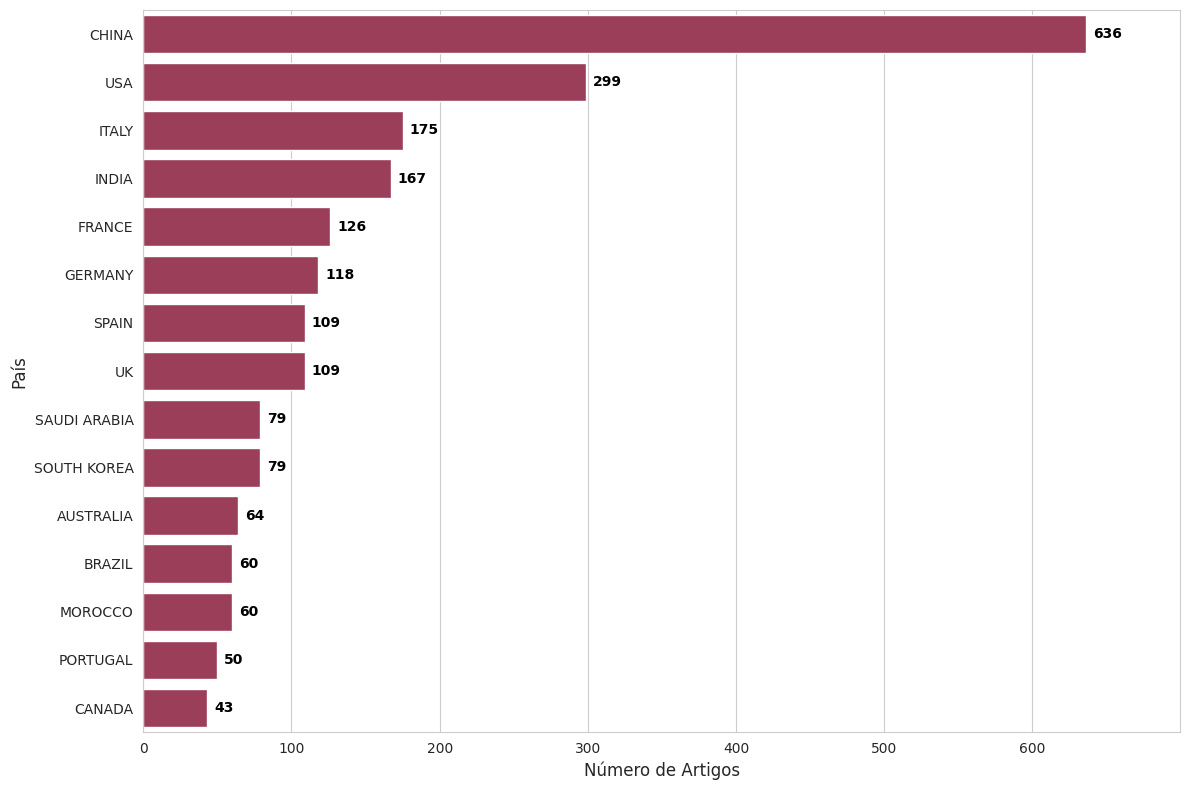

Gráfico salvo: graficos_wos_vs1/fig8_paises_mais_produtivos.png


In [10]:
# 8. CountrySciProd - Produção por País
df = pd.read_excel(xl, sheet_name='CountrySciProd').head(15)

plt.figure(figsize=(12, 8))

# Trocado palette por color #2E86AB para manter a identidade visual
ax = sns.barplot(data=df, x='Freq', y='region', color='#AB2E54', orient='h')

# Adiciona os valores (Frequência) após as barras
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold', color="#000000")

# Margem no eixo X para o número não ser cortado
plt.xlim(0, df['Freq'].max() * 1.1)

#plt.title('Países Mais Produtivos - Scopus', fontsize=14, fontweight='bold')
plt.xlabel('Número de Artigos', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig8_paises_mais_produtivos.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig8_paises_mais_produtivos.png")


## 9. Países Mais Citados

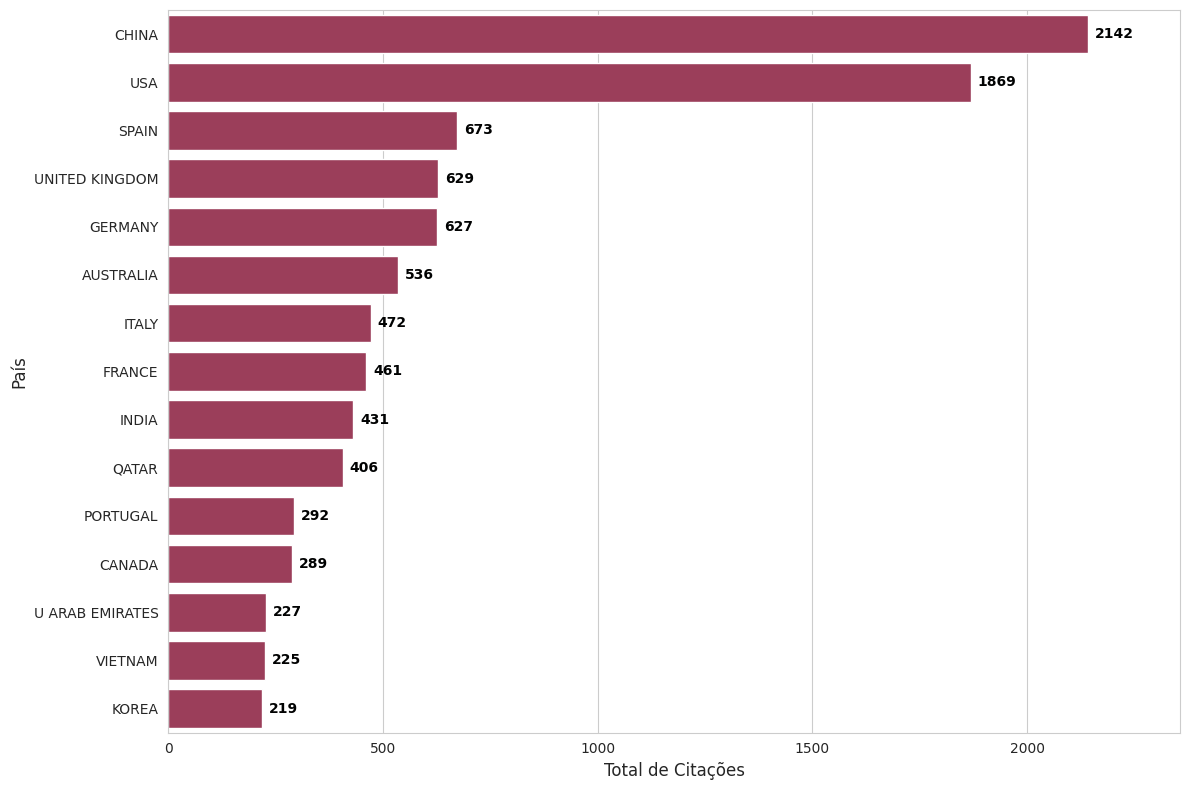

Gráfico salvo: graficos_wos_vs1/fig9_paises_mais_citados.png


In [11]:
# 9. MostCitCountries - Países Mais Citados
df = pd.read_excel(xl, sheet_name='MostCitCountries').head(15)

plt.figure(figsize=(12, 8))

# Trocado palette por color #2E86AB para manter a identidade visual
ax = sns.barplot(data=df, x='TC', y='Country', color='#AB2E54', orient='h')

# Adicionando os valores (Total de Citações) ao lado das barras
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold', color="#010202")

# Margem no eixo X para o número não ser cortado
plt.xlim(0, df['TC'].max() * 1.1)

#plt.title('Países Mais Citados - Scopus', fontsize=14, fontweight='bold')
plt.xlabel('Total de Citações', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig9_paises_mais_citados.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig9_paises_mais_citados.png")


## 10. Documentos Mais Citados Globalmente

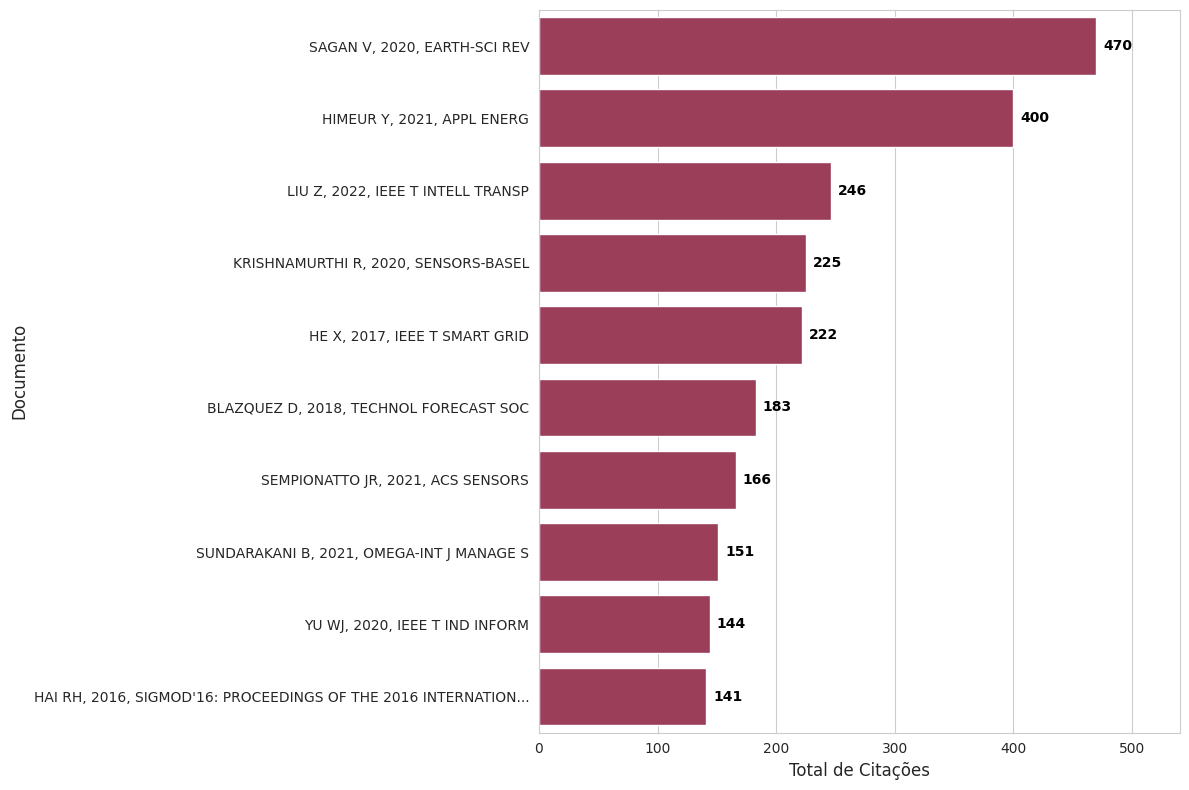

Gráfico salvo: graficos_wos_vs1/fig10_docs_mais_citados_global.png


In [12]:
# 10. MostGlobCitDocs - Documentos Mais Citados Globalmente
df = pd.read_excel(xl, sheet_name='MostGlobCitDocs').head(10)

# Limpar títulos (manter truncado para não poluir o gráfico)
df['Paper'] = df['Paper'].apply(lambda x: x[:60] + '...' if len(str(x)) > 60 else x)

plt.figure(figsize=(12, 8))

# Trocado palette por color #2E86AB para manter a identidade visual
ax = sns.barplot(data=df, x='Total Citations', y='Paper', color="#AB2E54", orient='h')

# Adicionando os valores (Total de Citações) ao lado das barras
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold', color="#000000")

# Margem no eixo X para o número (que costuma ser alto em citações globais) não ser cortado
plt.xlim(0, df['Total Citations'].max() * 1.15)

#plt.title('Documentos Mais Citados Globalmente - Scopus', fontsize=14, fontweight='bold')
plt.xlabel('Total de Citações', fontsize=12)
plt.ylabel('Documento', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig10_docs_mais_citados_global.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig10_docs_mais_citados_global.png")


## 11. Documentos Mais Citados Localmente

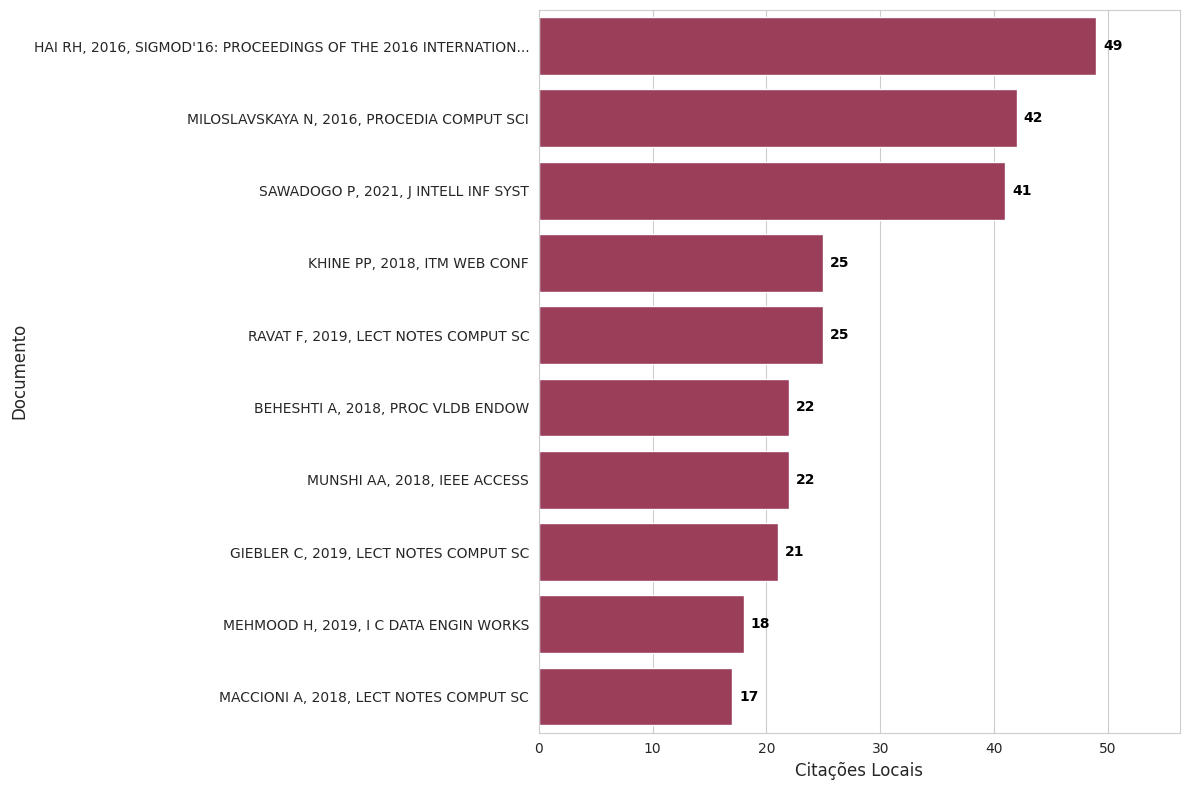

Gráfico salvo: graficos_wos_vs1/fig11_docs_mais_citados_local.png


In [13]:
# 11. MostLocCitDocs - Documentos Mais Citados Localmente
df = pd.read_excel(xl, sheet_name='MostLocCitDocs').head(10)

# Limpar títulos
df['Document'] = df['Document'].apply(lambda x: x[:60] + '...' if len(str(x)) > 60 else x)

plt.figure(figsize=(12, 8))

# Trocado palette por color #2E86AB para manter a identidade visual
ax = sns.barplot(data=df, x='Local.Citations', y='Document', color='#AB2E54', orient='h')

# Adicionando os valores (Citações Locais) ao lado das barras
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold', color="#000000")

# Margem no eixo X para o número não ser cortado
plt.xlim(0, df['Local.Citations'].max() * 1.15)

#plt.title('Documentos Mais Citados Localmente - Scopus', fontsize=14, fontweight='bold')
plt.xlabel('Citações Locais', fontsize=12)
plt.ylabel('Documento', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig11_docs_mais_citados_local.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig11_docs_mais_citados_local.png")


## 12. Palavras Mais Frequentes

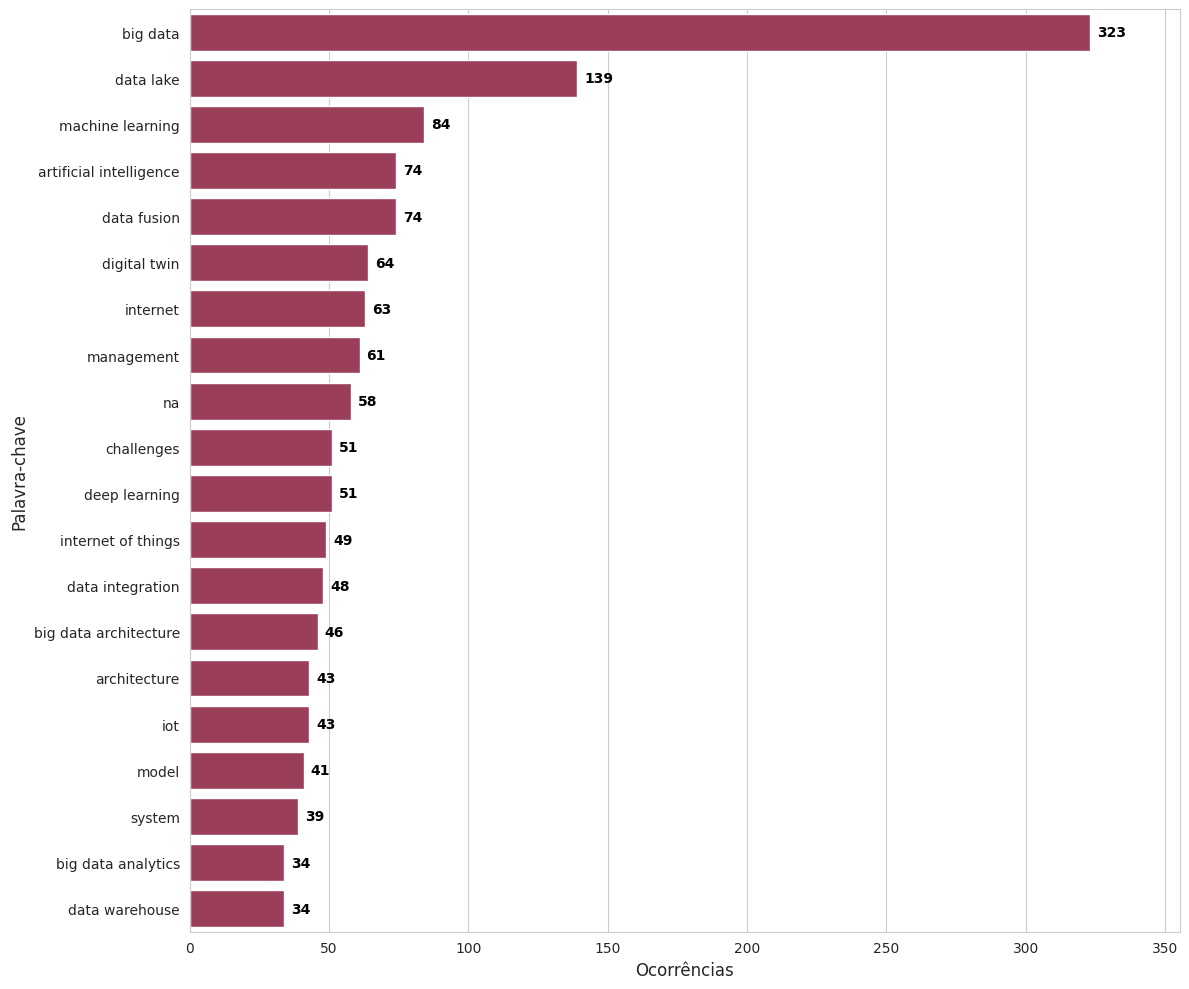

Gráfico salvo: graficos_wos_vs1/fig12_palavras_mais_frequentes.png


In [14]:
# 12. MostFreqWords - Palavras Mais Frequentes
df = pd.read_excel(xl, sheet_name='MostFreqWords').head(20)

plt.figure(figsize=(12, 10))

# Ajuste para cor única e remoção da paleta para evitar avisos de versão
ax = sns.barplot(data=df, x='Occurrences', y='Words', color='#AB2E54', orient='h')

# Adicionando o número de ocorrências ao lado das barras
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold', color="#000000")

# Margem no eixo X para o número não bater na borda
plt.xlim(0, df['Occurrences'].max() * 1.1)

#plt.title('Palavras Mais Frequentes - Scopus', fontsize=14, fontweight='bold')
plt.xlabel('Ocorrências', fontsize=12)
plt.ylabel('Palavra-chave', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig12_palavras_mais_frequentes.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig12_palavras_mais_frequentes.png")


## 13. Lei de Lotka

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not

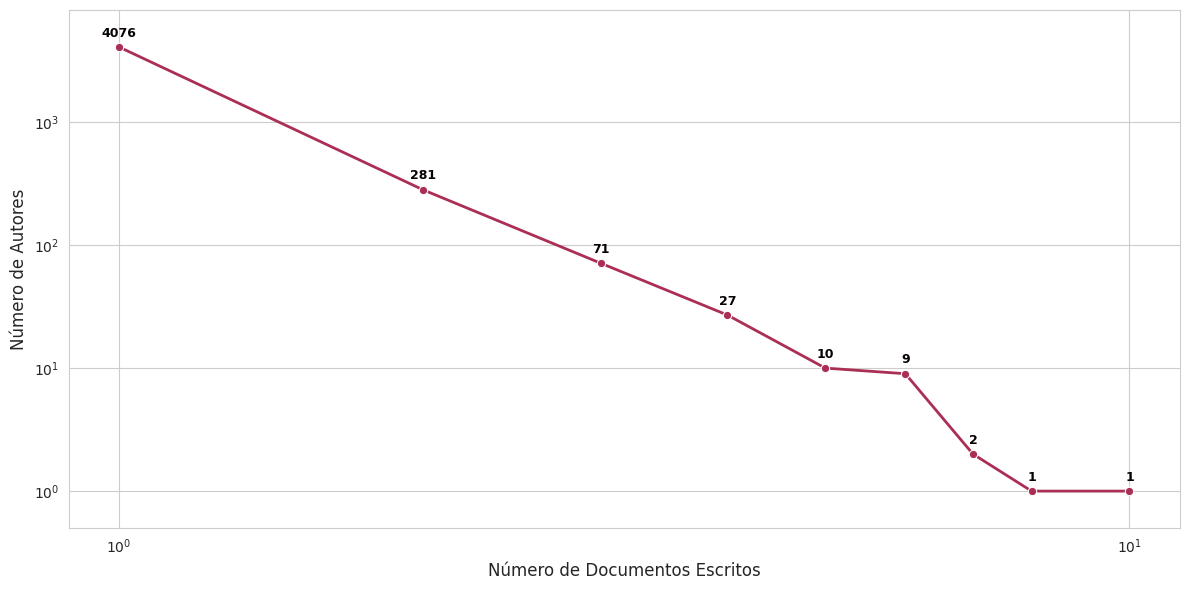

Gráfico salvo: graficos_wos_vs1/fig13_lei_lotka.png


In [15]:
# 13. LotkaLaw - Lei de Lotka
df = pd.read_excel(xl, sheet_name='LotkaLaw')

plt.figure(figsize=(12, 6))
# Plotando a linha
ax = sns.lineplot(data=df, x='Documents written', y='N. of Authors', marker='o', linewidth=2, color='#AB2E54')

# Adicionando os valores acima dos pontos
# Como a escala é logarítmica, usamos um multiplicador (* 1.1) em vez de uma soma fixa (+ 0.5)
for i in range(len(df)):
    plt.text(df['Documents written'].iloc[i], 
             df['N. of Authors'].iloc[i] * 1.15, # 15% acima do ponto na escala log
             str(int(df['N. of Authors'].iloc[i])), 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color="#070201")

#plt.title('Lei de Lotka - Distribuição de Produtividade dos Autores - Scopus', fontsize=14, fontweight='bold')
plt.xlabel('Número de Documentos Escritos', fontsize=12)
plt.ylabel('Número de Autores', fontsize=12)

# Mantendo suas escalas logarítmicas
plt.xscale('log')
plt.yscale('log')

# Ajuste fino do limite Y para o texto do primeiro ponto não ser cortado
plt.ylim(df['N. of Authors'].min() * 0.5, df['N. of Authors'].max() * 2)

plt.tight_layout()
plt.savefig(f'{output_dir}/fig13_lei_lotka.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig13_lei_lotka.png")


## 14. Lei de Bradford

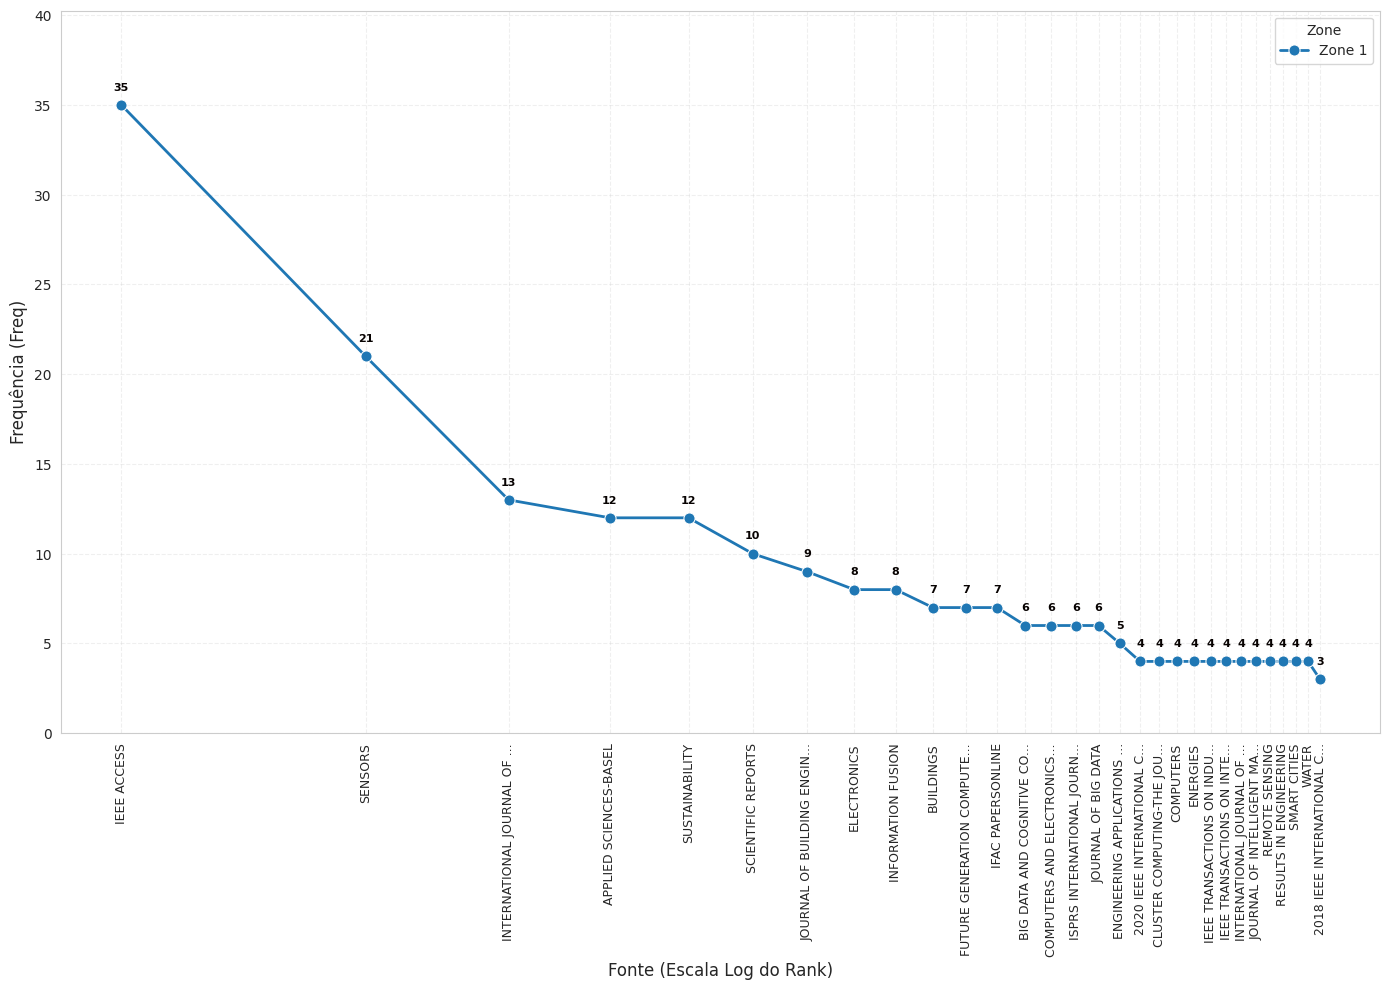

Gráfico salvo: graficos_wos_vs1/fig14_lei_bradford.png


In [18]:
import numpy as np

# 14. BradfordLaw - Lei de Bradford
df = pd.read_excel(xl, sheet_name='BradfordLaw').head(30)

# 1. Calcular o Log do Rank
df['logRank'] = np.log10(df['Rank'])

# 2. Recortar os nomes das fontes (SO) para 25 caracteres
df['SO_short'] = df['SO'].apply(lambda x: str(x)[:25] + '...' if len(str(x)) > 25 else x)

plt.figure(figsize=(14, 10)) # Aumentei a altura para acomodar os nomes em 90°

# 3. Criar o gráfico
ax = sns.lineplot(data=df, x='logRank', y='Freq', hue='Zone', marker='o', 
                  linewidth=2, markersize=8, color="#AB2E54")

# 4. Adicionar os valores (Frequência) acima de cada ponto
offset = df['Freq'].max() * 0.02
for i in range(len(df)):
    plt.text(df['logRank'].iloc[i], 
             df['Freq'].iloc[i] + offset, 
             str(int(df['Freq'].iloc[i])), 
             ha='center', va='bottom', fontsize=8, fontweight='bold', color="#070201")

# 5. Mudar os rótulos: nomes curtos e rotação de 90 graus
plt.xticks(ticks=df['logRank'], labels=df['SO_short'], rotation=90, ha='center', fontsize=9)

# Ajustes finais
plt.ylim(0, df['Freq'].max() * 1.15)
plt.xlabel('Fonte (Escala Log do Rank)', fontsize=12)
plt.ylabel('Frequência (Freq)', fontsize=12) # Ajustado para Freq
#plt.legend(title='Zona', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/fig14_lei_bradford.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig14_lei_bradford.png")


## 15. Tópicos de Tendência

<Figure size 1400x800 with 0 Axes>

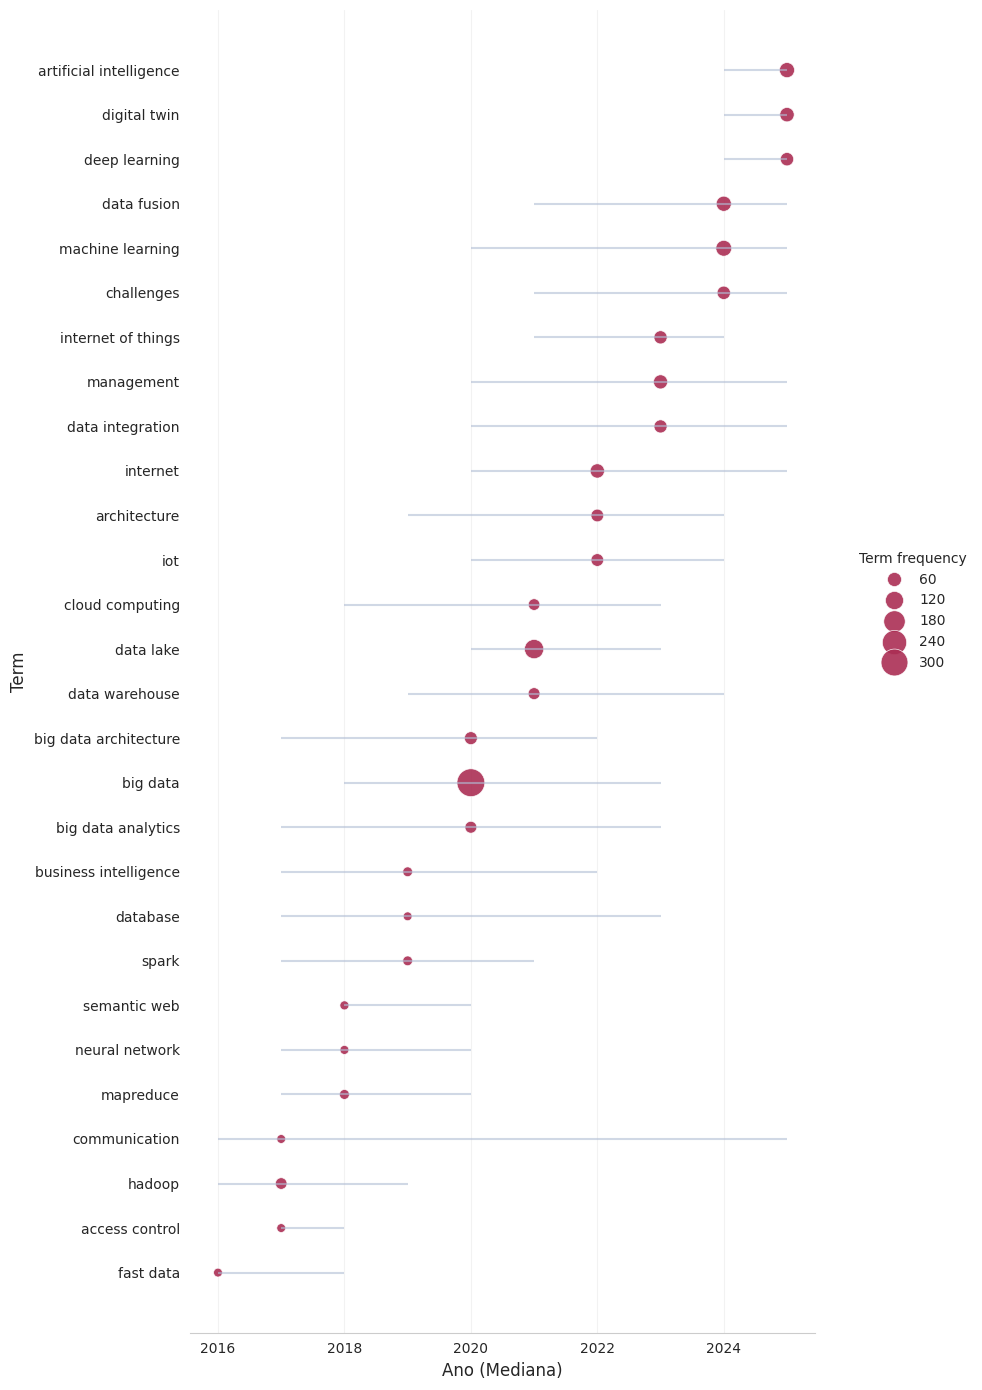

Gráfico salvo: graficos_wos_vs1/fig15_topicos_tendencia.png


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt




df = pd.read_excel(xl, sheet_name='TrendTopics').head(30)



df = df.sort_values('Year (Median)', ascending=False)
plt.figure(figsize=(14, 8))
# 2. Configurar o estilo visual
sns.set_style("whitegrid", {'axes.grid': False}) # Fundo limpo
plt.figure(figsize=(10, 14)) # Proporção vertical para caber todos os termos

# 3. Desenhar as linhas de intervalo (Q1 até Q3)
# Essas são as linhas azuis claras que indicam a duração da tendência
plt.hlines(y=df['Term'], xmin=df['Year (Q1)'], xmax=df['Year (Q3)'], 
           color='#b1bed5', linewidth=1.5, alpha=0.6)

# 4. Desenhar os pontos na Mediana com o tamanho variando pela Frequência
# O argumento 'hue' pode ser usado se você quiser cores diferentes, mas a imagem usa azul padrão
ax = sns.scatterplot(
    data=df, 
    x='Year (Median)', 
    y='Term', 
    size='Frequency', 
    sizes=(40, 400), # Ajusta o diâmetro dos círculos (mínimo e máximo)
    color='#AB2E54',
    alpha=0.9,
    edgecolor='white'
)



#plt.title('Tópicos de Tendência ao Longo do Tempo - Scopus', fontsize=14, fontweight='bold')
plt.xlabel('Ano (Mediana)', fontsize=12)
plt.ylabel('Term', fontsize=12)

# Remove as bordas laterais e superior para ficar "clean"
sns.despine(left=True, bottom=False)

# Adiciona grades verticais apenas nos anos (como na imagem)
plt.grid(axis='x', color='grey', linestyle='-', alpha=0.1)

# Ajusta a legenda da frequência
plt.legend(title='Term frequency', bbox_to_anchor=(1.05, 0.6), loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig(f'{output_dir}/fig15_topicos_tendencia.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig15_topicos_tendencia.png")


## 16. Impacto das Fontes

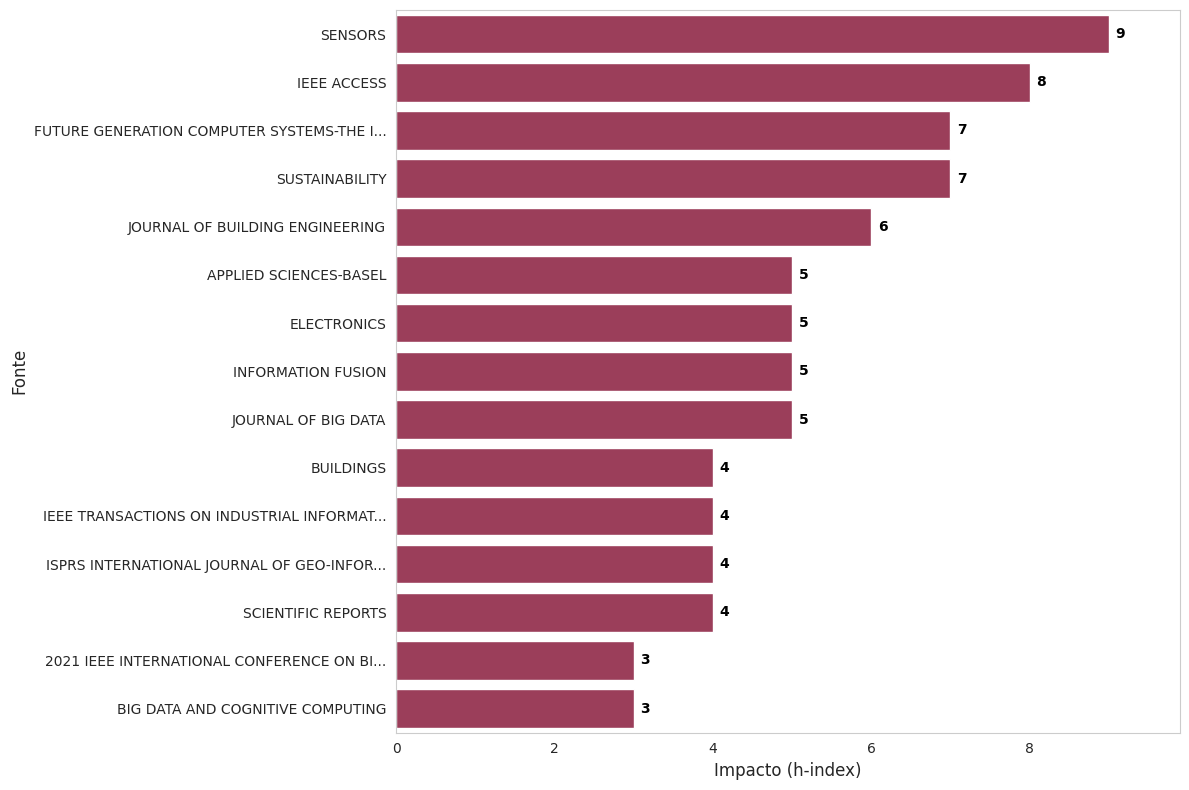

Gráfico salvo: graficos_wos_vs1/fig16_impacto_fontes.png


In [20]:
# 16. SourceLocImpact - Impacto Local das Fontes
df = pd.read_excel(xl, sheet_name='SourceLocImpact').head(15)

# Limpar nomes
df['Source'] = df['Source'].apply(lambda x: x[:40] + '...' if len(str(x)) > 40 else x)

# --- APLICAÇÃO DO DESIGN DO GRÁFICO 12 ---
plt.figure(figsize=(12, 8))

# 1. Uso da cor sólida e orientação horizontal
ax = sns.barplot(data=df, x='h_index', y='Source', color='#AB2E54', orient='h')

# 2. Adição dos rótulos (bar_label) com o mesmo estilo
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold', color="#000000")

# 3. Ajuste de margem dinâmica no eixo X
plt.xlim(0, df['h_index'].max() * 1.1)

# 4. Padronização de fontes e títulos
plt.xlabel('Impacto (h-index)', fontsize=12)
plt.ylabel('Fonte', fontsize=12)
# plt.title('Impacto das Fontes - Scopus', fontsize=14, fontweight='bold') # Opcional

plt.tight_layout()
# ---------------------------------------

plt.savefig(f'{output_dir}/fig16_impacto_fontes.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig16_impacto_fontes.png")


## 17. Análise de Coupling

Esse eu retirei direto do *Biblioshiny()* porque não consegui fazer por aqui

Buscar os gráficos:

1. Coupling Map
2. Coupling Network

## 18. Análise de Co-Ocorrencia

Esse eu também não consegui fazer sozinho, tem que puxar do *biblioshiny()*

Buscar os gráficos:

1. Co-word network

## 19. Análise de Co-citação

Esse eu também não consegui fazer sozinho, tem que puxar do *biblioshiny()*

Buscar os gráficos:

1. Co-citation network

## 20. Referências locais mais citadas

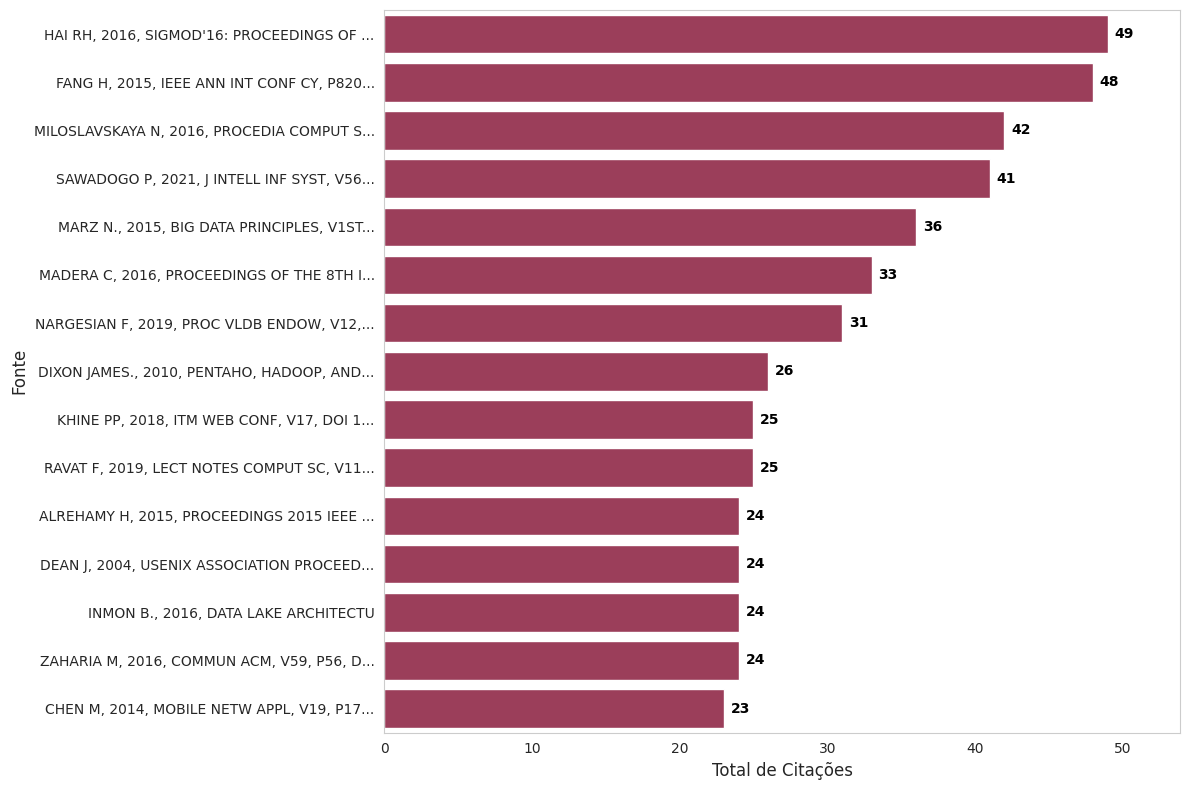

Gráfico salvo: graficos_wos_vs1/fig24_Referencias_Locais_Citadas_Importantes.png


In [21]:
#MostLocCitRefs
df = pd.read_excel(xl, sheet_name='MostLocCitRefs').head(15)

# Limpar nomes
df['Cited References'] = df['Cited References'].apply(lambda x: x[:40] + '...' if len(str(x)) > 40 else x)

# --- APLICAÇÃO DO DESIGN DO GRÁFICO 12 ---
plt.figure(figsize=(12, 8))

# 1. Uso da cor sólida e orientação horizontal
ax = sns.barplot(data=df, x='Citations', y='Cited References', color='#AB2E54', orient='h')

# 2. Adição dos rótulos (bar_label) com o mesmo estilo
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold', color="#000000")

# 3. Ajuste de margem dinâmica no eixo X
plt.xlim(0, df['Citations'].max() * 1.1)

# 4. Padronização de fontes e títulos
plt.xlabel('Total de Citações', fontsize=12)
plt.ylabel('Fonte', fontsize=12)
# plt.title('Impacto das Fontes - Scopus', fontsize=14, fontweight='bold') # Opcional

plt.tight_layout()
# ---------------------------------------

plt.savefig(f'{output_dir}/fig24_Referencias_Locais_Citadas_Importantes.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo: {output_dir}/fig24_Referencias_Locais_Citadas_Importantes.png")

## 21. Grafo histórico

Buscar os gráficos:

1. Historiograph

## 22. Mapa temático

Buscar os gráficos:

1. ThematicMap